In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import pprint

In [3]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM

In [4]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x7c41cd396d70>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x7c41cd208c40>, root_client=<openai.OpenAI object at 0x7c41cf5fb100>, root_async_client=<openai.AsyncOpenAI object at 0x7c41cd396da0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the Graph state

State is the object that is passed between nodes in the graph.

In [5]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage # type: ignore
from IPython.display import Image, display

In [6]:
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    input: str
    agent_outcome: List[AnyMessage]
    chat_history: Annotated[list, add_messages]

**[Reducers](https://langchain-ai.github.io/langgraph/concepts/low_level/)** helps in appending the updates from nodes (agents) to the graph state.

In previous notebook we've used the `Annotated` type to specify a reducer function `(operator.add)`.

Langgraph provides a built-in reducer `add_message` for updating the graph state with new `Messages`

### Define the agent (node)

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant"
                "\nUser Query: {input}"
            ),
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    agent = prompt | llm
    result = agent.invoke(data)
    return {
                'agent_outcome': [result],
                'chat_history': [result],
            }

### Defining the workflow (graph)

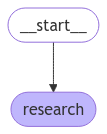

In [8]:
from langgraph.graph import END, StateGraph

## Initialising the workflow
workflow = StateGraph(AgentState)

## Adding node (agent) to the graph (workflow)
workflow.add_node("research", research_agent)

## Setting the entry point of the graph
workflow.set_entry_point("research")

## Compiling the graph
app = workflow.compile()
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
from langchain_core.messages import HumanMessage
inputs = {
    "input": "What are Small Language Models?",
}
inputs["chat_history"] = HumanMessage(inputs["input"])
agen_stream = app.invoke(input=inputs)
agen_stream

{'input': 'What are Small Language Models?',
 'agent_outcome': [AIMessage(content='Small Language Models (SLMs) refer to natural language processing (NLP) models that are designed to be smaller in size and computational requirements compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which makes them faster to train and deploy, and they can be more efficient in terms of memory usage and processing power.\n\nKey characteristics of Small Language Models include:\n\n1. **Reduced Size**: SLMs have fewer parameters (often in the millions rather than billions), which allows them to run on devices with limited computational resources, such as mobile phones or edge devices.\n\n2. **Efficiency**: Due to their smaller size, these models can be trained and fine-tuned more quickly, making them suitable for applications where rapid iteration is needed.\n\n3. **Specificity**: SLMs can be tailored for specific tasks or domains, allowing them to 

In [10]:
for msg in agen_stream["chat_history"]:
    msg.pretty_print()

================================ Human Message =================================

What are Small Language Models?
================================== Ai Message ==================================

Small Language Models (SLMs) refer to natural language processing (NLP) models that are designed to be smaller in size and computational requirements compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which makes them faster to train and deploy, and they can be more efficient in terms of memory usage and processing power.

Key characteristics of Small Language Models include:

1. **Reduced Size**: SLMs have fewer parameters (often in the millions rather than billions), which allows them to run on devices with limited computational resources, such as mobile phones or edge devices.

2. **Efficiency**: Due to their smaller size, these models can be trained and fine-tuned more quickly, making them suitable for applications where rapid iterat